<a href="https://colab.research.google.com/github/PariSharma-commits/Learning_ML/blob/main/FunctionTransformer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import FunctionTransformer
from sklearn.compose import ColumnTransformer

In [9]:
df=pd.read_csv('Titanic.csv', usecols=['age', 'fare', 'survived'])

In [10]:
df.head()

,survived,age,fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [11]:
df['age'] = df['age'].fillna(df['age'].mean())

In [12]:
df.isnull().sum()

,0
survived,0
age,0
fare,0


In [13]:
x=df.iloc[:, 1:3]
y=df.iloc[:, 0]

In [14]:
X_train, X_test, y_train, y_test= train_test_split(x, y, test_size=0.2, random_state=42)

/tmp/ipykernel_1450/1248906638.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train['age'])


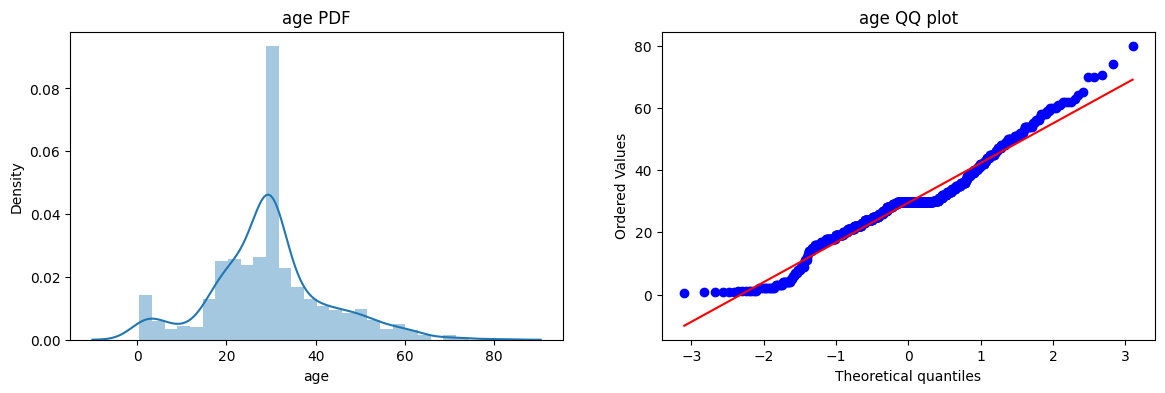

In [15]:
plt.figure(figsize=(14, 4))
plt.subplot(121)
sns.distplot(X_train['age'])
plt.title('age PDF')

plt.subplot(122)
stats.probplot(X_train['age'], dist="norm", plot=plt)
plt.title('age QQ plot')
plt.show()

/tmp/ipykernel_1450/2826878593.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train['fare'])


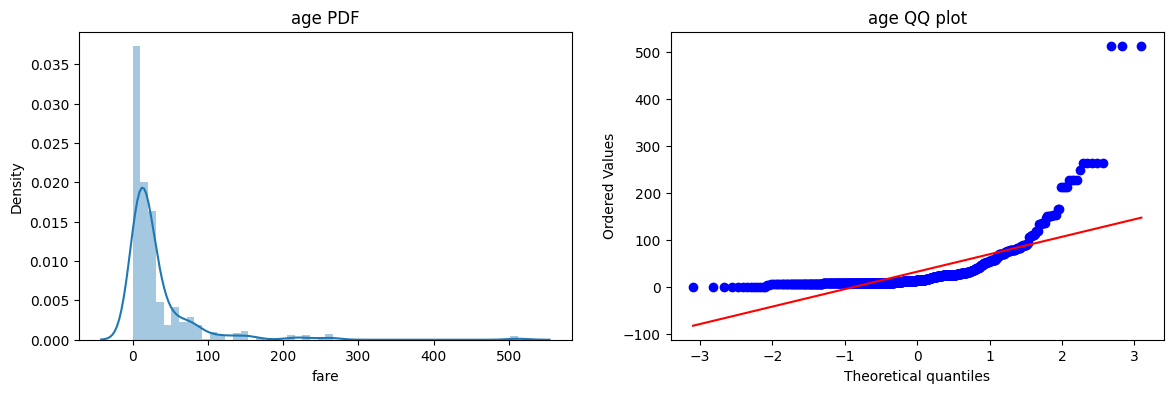

In [16]:
plt.figure(figsize=(14, 4))
plt.subplot(121)
sns.distplot(X_train['fare'])
plt.title('age PDF')

plt.subplot(122)
stats.probplot(X_train['fare'], dist="norm", plot=plt)
plt.title('age QQ plot')
plt.show()

In [17]:
clf=LogisticRegression()
clf2=DecisionTreeClassifier()

In [18]:
clf.fit(X_train, y_train)
clf2.fit(X_train, y_train)
y_pred=clf.predict(X_test)
y_pred1=clf2.predict(X_test)
print("Accuracy LR", accuracy_score(y_test, y_pred))
print("Accuracy DT", accuracy_score(y_test, y_pred1))

Accuracy LR 0.6480446927374302
Accuracy DT 0.6703910614525139


In [19]:
trf=FunctionTransformer(func=np.log1p)

In [20]:
X_train_transformed=trf.fit_transform(X_train)
X_test_transformed=trf.transform(X_test)

In [21]:
clf=LogisticRegression()
clf2=DecisionTreeClassifier()
clf.fit(X_train_transformed, y_train)
clf2.fit(X_train_transformed, y_train)
y_pred=clf.predict(X_test_transformed)
y_pred1=clf2.predict(X_test_transformed)
print("Accuracy LR", accuracy_score(y_test, y_pred))
print("Accuracy DT", accuracy_score(y_test, y_pred1))

Accuracy LR 0.6815642458100558
Accuracy DT 0.6759776536312849


In [22]:
X_transformed= trf.fit_transform(x)
clf=LogisticRegression()
clf2=DecisionTreeClassifier()
print("LR", np.mean(cross_val_score(clf, X_transformed, y, cv=10, scoring='accuracy')))
print("DT", np.mean(cross_val_score(clf2, X_transformed, y, cv=10, scoring='accuracy')))

LR 0.678027465667915
DT 0.6588639200998753


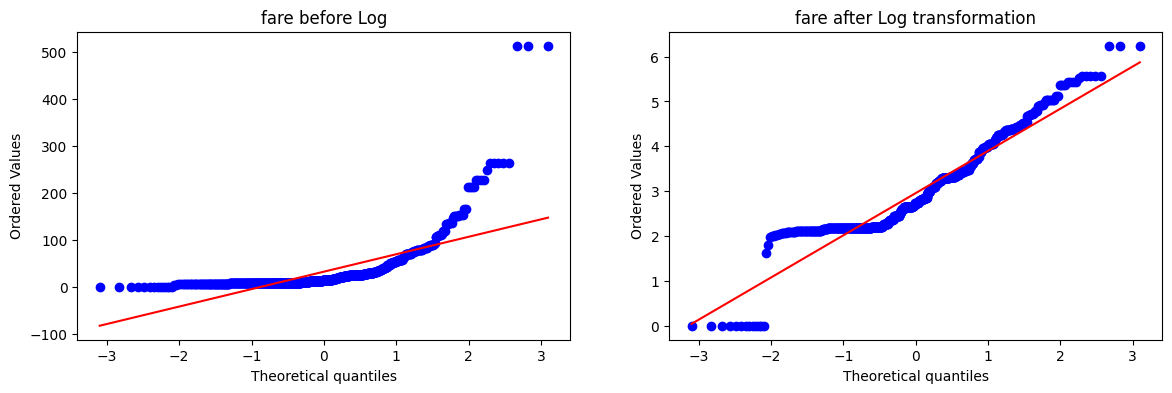

In [25]:
plt.figure(figsize=(14, 4))
plt.subplot(121)
stats.probplot(X_train['fare'], dist="norm", plot=plt)
plt.title('fare before Log')

plt.subplot(122)
stats.probplot(np.log1p(X_train['fare']), dist="norm", plot=plt)
plt.title('fare after Log transformation')
plt.show()

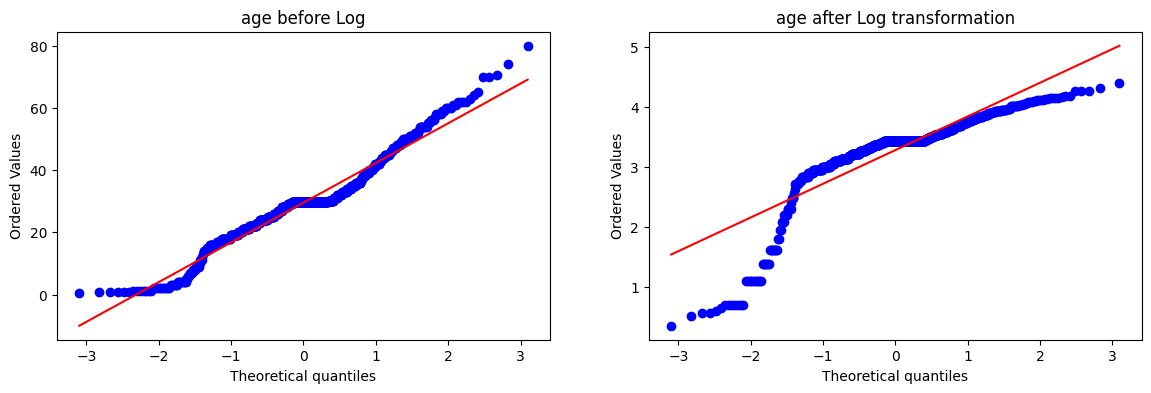

In [26]:
plt.figure(figsize=(14, 4))
plt.subplot(121)
stats.probplot(X_train['age'], dist="norm", plot=plt)
plt.title('age before Log')

plt.subplot(122)
stats.probplot(np.log1p(X_train['age']), dist="norm", plot=plt)
plt.title('age after Log transformation')
plt.show()

In [28]:
trf2 = ColumnTransformer([('log', FunctionTransformer(np.log1p), ['fare'])], remainder='passthrough')

X_train_transformed2 = trf2.fit_transform(X_train)
X_test_transformed2 = trf2.transform(X_test)

In [29]:
clf = LogisticRegression()
clf2 = DecisionTreeClassifier()

clf.fit(X_train_transformed2, y_train)
clf2.fit(X_train_transformed2, y_train)

y_pred = clf.predict(X_test_transformed2)
y_pred2 = clf2.predict(X_test_transformed2)

print("Accuracy LR", accuracy_score(y_test, y_pred))
print("Accuracy DT", accuracy_score(y_test, y_pred2))

Accuracy LR 0.6703910614525139
Accuracy DT 0.664804469273743


In [31]:
X_transformed2 = trf2.fit_transform(x)

clf = LogisticRegression()
clf2 = DecisionTreeClassifier()

print("LR", np.mean(cross_val_score(clf, X_transformed2, y, scoring='accuracy', cv=10)))
print("DT", np.mean(cross_val_score(clf2, X_transformed2, y, scoring='accuracy', cv=10)))

LR 0.6712609238451936
DT 0.6632958801498127


In [36]:
def apply_transform(transform):
    X = df.iloc[:,1:3]
    y = df.iloc[:,0]

    trf = ColumnTransformer(
        [('log', FunctionTransformer(transform), ['fare'])],
        remainder='passthrough'
    )

    X_trans = trf.fit_transform(X)

    clf = LogisticRegression()

    print("Accuracy",
          np.mean(cross_val_score(clf, X_trans, y,
                                  scoring='accuracy', cv=10)))

    plt.figure(figsize=(14,4))

    plt.subplot(121)
    stats.probplot(X['fare'], dist="norm", plot=plt)
    plt.title('fare Before Transform')

    plt.subplot(122)
    stats.probplot(X_trans[:,0], dist="norm", plot=plt)
    plt.title('fare After Transform')

    plt.show()

Accuracy 0.6589013732833957


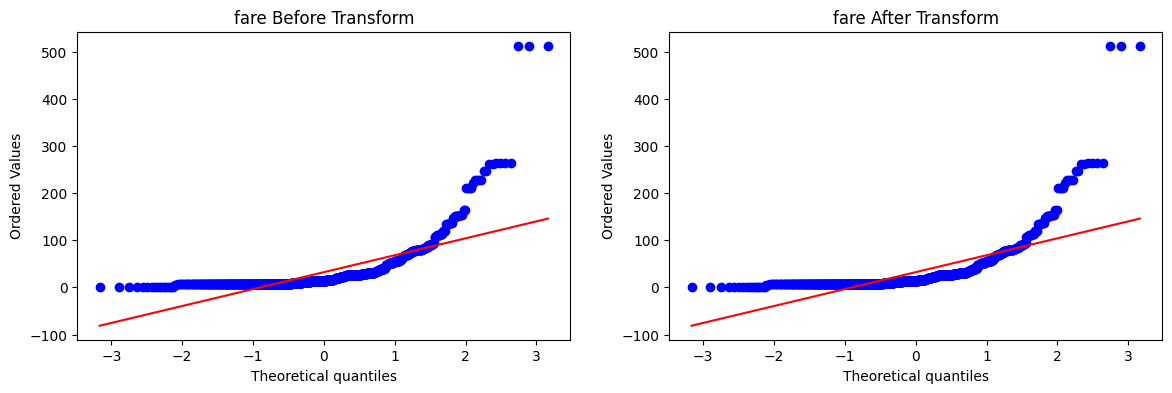

In [37]:
apply_transform(lambda x: x)

Accuracy 0.6431335830212235


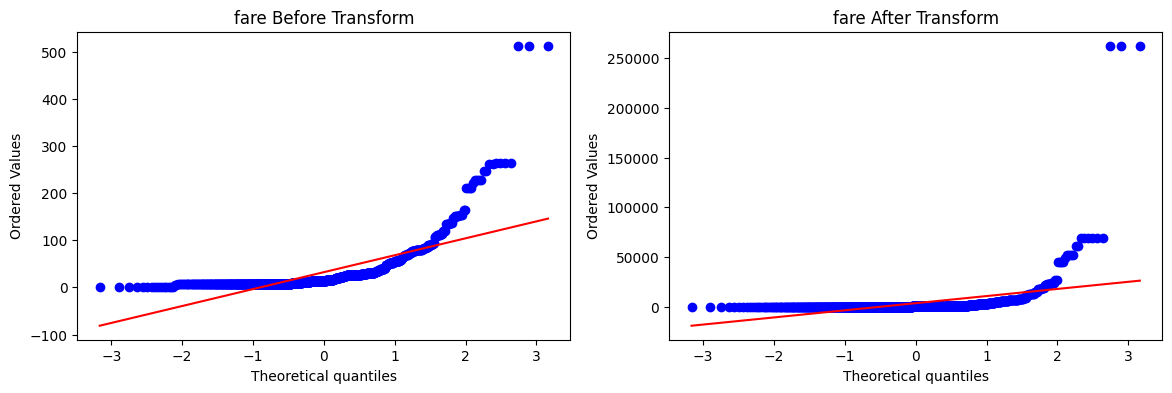

In [39]:
apply_transform(lambda x: x**2)

Accuracy 0.6589013732833957


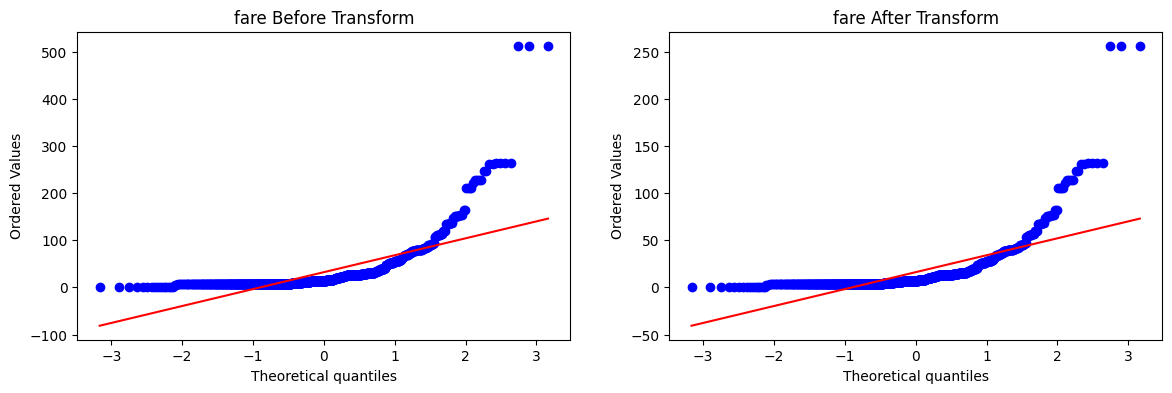

In [42]:
apply_transform(lambda x: x**1/2)

Accuracy 0.61729088639201


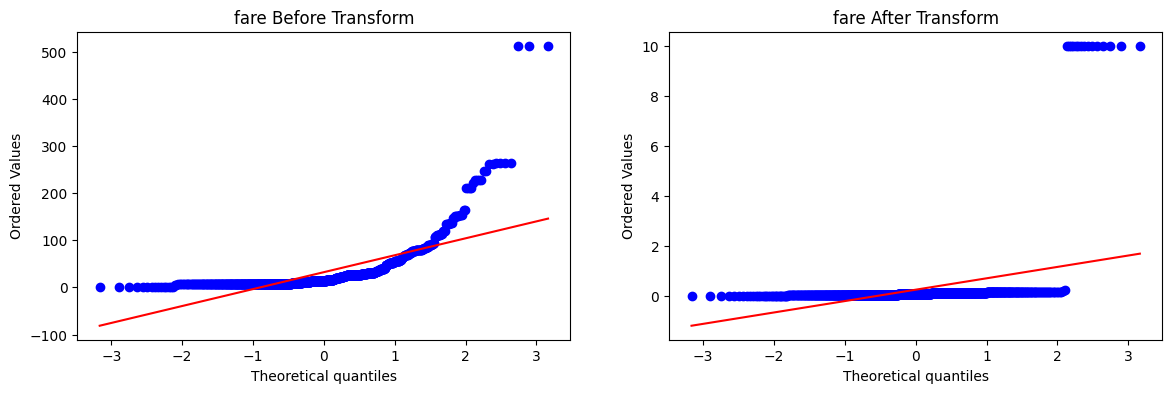

In [43]:
apply_transform(lambda x: 1/(x+0.1))

Accuracy 0.6195131086142323


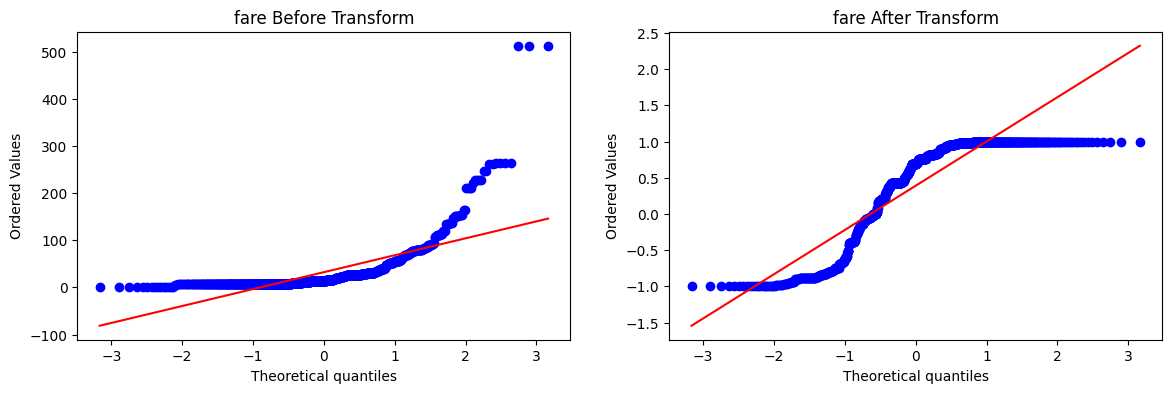

In [44]:
apply_transform(np.sin)